In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tqdm import tqdm
import yaml
from torchgeodemo import autoencoder_train_latent
import torch
import os


#notebook to rest reconstruction error of PCA

random_seed_number = 20210321  # 2021 UK Census date used as random seed
def set_random_seeds(seed):
    # """Set random seeds for reproducibility."""
    torch.manual_seed(seed)  # Set seed for PyTorch


# Set the seed
set_random_seeds(seed=random_seed_number)

def gen_layer_sizes(input_size,latent_size,num_layers,scaling_type = "mul"):

    """
    Generate layer sizes for a neural network based on the input size, latent size, number of layers, and scaling type.

    Args:
        input_size (int): The size of the input layer.
        latent_size (int): The size of the latent layer.
        num_layers (int): The number of layers in the network.
        scaling_type (str): The type of scaling to use. Can be "mul" or "lin".

    Returns:
        list: A list containing the sizes of each layer in the network.
    """
    if scaling_type == "mul":
        # Geometric scaling
        scale_factor = (latent_size / input_size) ** (1 / (num_layers - 1))
        layer_sizes = [int(input_size * scale_factor ** i) for i in range(num_layers)]
    elif scaling_type == "lin":
        # Linear scaling
        step = (latent_size - input_size) / (num_layers - 1)
        layer_sizes = [int(input_size + step * i) for i in range(num_layers)]
    else:
        raise ValueError("Invalid scaling type. Use 'mul' or 'lin'.")

    #for torchgeodemo dont want to include the input layer
    layer_sizes = layer_sizes[1:]  # Exclude input layer size
    return layer_sizes

In [2]:
#load the cleaned data
data_name = "engcensus_all"
cleaned_data_path = "../data/census_data/engcensus_cleaned_scaled.parquet"
df_scaled = pd.read_parquet(cleaned_data_path)
df_scaled

,OA,ts0010002,ts0010003,ts0020002,ts0020003,ts0020004,ts0020005,ts0020006,ts0020007,ts0020008,...,ts0670007,ts0670008,ts0680002,ts0680003,ts0750002,ts0750003,ts0750004,ts0750005,ts0750006,ts0750007
0,E00000001,1.000,0.000,0.209,0.595,0.546,0.472,0.074,0.049,0.0,...,0.762,0.031,0.102,0.898,0.362,0.043,0.223,0.287,0.074,0.011
1,E00000003,1.000,0.000,0.309,0.599,0.581,0.553,0.028,0.018,0.0,...,0.833,0.000,0.180,0.820,0.243,0.054,0.198,0.252,0.225,0.027
2,E00000005,1.000,0.000,0.406,0.396,0.377,0.377,0.000,0.019,0.0,...,0.830,0.000,0.047,0.953,0.413,0.032,0.190,0.254,0.063,0.048
3,E00000007,1.000,0.000,0.712,0.209,0.209,0.209,0.000,0.000,0.0,...,0.842,0.014,0.109,0.891,0.437,0.034,0.218,0.195,0.103,0.011
4,E00000010,1.000,0.000,0.772,0.170,0.170,0.158,0.012,0.000,0.0,...,0.541,0.047,0.062,0.938,0.762,0.000,0.071,0.111,0.056,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188875,W00010693,0.101,0.899,0.946,0.018,0.018,0.018,0.000,0.000,0.0,...,0.198,0.022,0.927,0.073,0.789,0.000,0.053,0.140,0.018,0.000
188876,W00010694,1.000,0.000,0.303,0.536,0.530,0.530,0.000,0.007,0.0,...,0.474,0.010,0.252,0.748,0.233,0.019,0.321,0.233,0.189,0.006
188877,W00010695,1.000,0.000,0.263,0.558,0.558,0.558,0.000,0.000,0.0,...,0.305,0.052,0.182,0.818,0.257,0.014,0.473,0.189,0.068,0.000
188878,W00010696,1.000,0.000,0.309,0.573,0.562,0.551,0.011,0.011,0.0,...,0.480,0.006,0.132,0.868,0.208,0.000,0.208,0.385,0.188,0.010


In [ ]:

epochs = 500
scaling_type = "lin"  # "mul" for geometric scaling, "lin" for linear scaling
# Define the run name and working directory - NEW output location
run_name = f"{epochs}epoch_rerun_{scaling_type}"
WORKING_DIR = "../AE_outputs/" + data_name + "/" + run_name
os.makedirs(WORKING_DIR, exist_ok=True)
# Output directory for generated YAMLs
OUTPUT_DIR = WORKING_DIR + "/yamls"
os.makedirs(OUTPUT_DIR, exist_ok=True)

bottleneck_sizes = [128]  # Only 100D
input_size = len(df_scaled.columns) - 1
encoder_layer_sizes = []
for bottleneck_size in bottleneck_sizes:
    encoder_layer_sizes.append(gen_layer_sizes(input_size, bottleneck_size, 4, scaling_type=scaling_type))

print(f"Working dir: {WORKING_DIR}")
print(f"Bottleneck sizes: {bottleneck_sizes}")
print(f"Encoder layer sizes: {encoder_layer_sizes}")

def plot_loss(WORKING_DIR, data_nickname, ae_nickname):
    # Load the loss data
    loss_data = pd.read_csv(WORKING_DIR + f"/logs/log_{data_nickname}_{ae_nickname}_v1/version_1/metrics.csv")[['epoch', 'train_loss_epoch', 'recon_loss_epoch']]
    #drop rows with nan
    loss_data = loss_data.dropna()
    plt.plot(loss_data["epoch"], loss_data["train_loss_epoch"], label="Training Loss")
    plt.plot(loss_data["epoch"], loss_data["recon_loss_epoch"], label="Reconstruction Loss")
    plt.legend()
    plt.show()


Working dir: ../AE_outputs/engcensus_all/250epoch_rerun_lin
Bottleneck sizes: [100]
Encoder layer sizes: [[305, 202, 100]]



geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [100, 202, 305]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [305, 202, 100]}, 'max_epochs': 250, 'nickname': 'bottleneck_100', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo', 'source': '../data/census_data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../AE_outputs/engcensus_all/250epoch_rerun_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'use_covariance_loss': False, 'decoder_sizes': [100, 202, 305, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=305, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=305, out_features=202, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=202, out_features

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA RTX A500 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode  | FLOPs
----------------------

Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 47.67it/s, v_num=0_1, recon_loss_step=0.0011, train_loss_step=0.0011, recon_loss_epoch=0.00111, train_loss_epoch=0.00111]  

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 47.20it/s, v_num=0_1, recon_loss_step=0.0011, train_loss_step=0.0011, recon_loss_epoch=0.00111, train_loss_epoch=0.00111]
Reconstructed outputs saved to ../AE_outputs/engcensus_all/250epoch_rerun_lin/census_geodemo__bottleneck_100_v1__reconstructed_outputs.csv


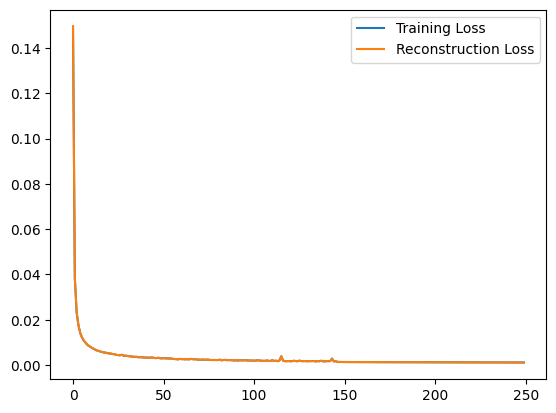

In [ ]:
# Set the seed
set_random_seeds(seed=random_seed_number)
# Define the base YAML structure as a dictionary
BASE_YAML = {
    "data": {
        "source": cleaned_data_path,
        "nickname": "PLACEHOLDER",
        "id_col": "OA"
    },
    "working_dir": WORKING_DIR,
    "autoencoder": {
        "nickname": "bottleneck_PLACEHOLDER",
        "version": "1",
        "save_latent": "csv",
        "max_epochs": epochs,
        "batch_size": 0.01,
        "use_covariance_loss": False,
        "encoder": {
            "sizes": "PLACEHOLDER",
            "activation": "LeakyReLU"
        },
        "decoder": {
            "sizes":  "PLACEHOLDER",
            "activation": "LeakyReLU"
        }
    }
}

data_nickname = "census_geodemo"1
# Generate YAML files with varying latent space sizes
for encoder_layer_size in encoder_layer_sizes:
    _latent_size = encoder_layer_size[-1]  # Last element is the bottleneck size
    ae_nickname = f"bottleneck_{_latent_size}"
    yaml_config = BASE_YAML.copy()
    yaml_config["autoencoder"]["encoder"]["sizes"] = encoder_layer_size
    yaml_config["autoencoder"]["decoder"]["sizes"] = encoder_layer_size[::-1] #reversed for encoder
    yaml_config["autoencoder"]["nickname"] = ae_nickname
    yaml_config["data"]["nickname"] = data_nickname

    config_path = os.path.join(OUTPUT_DIR, f"config_{_latent_size}.yaml")
    with open(config_path, "w") as yaml_file:
        yaml.dump(yaml_config, yaml_file, default_flow_style=False)

    autoencoder_train_latent.main(config_path, create_latent=True,save_reco_error=True, verbose=True)
    plot_loss(WORKING_DIR,data_nickname,ae_nickname)